In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [ ]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("../docs/tutorials/tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

In [3]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
spf_params = DoubleHenyeyGreenstein_SPF.params
psf_params = EMP_PSF.params

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30

# Initializing the misc parameter dictionary
misc_params = Parameter_Index.misc_params

# Setting flux_scaling to custom value
misc_params['flux_scaling'] = 1e4

simple_disk_img = objective_model(disk_params, spf_params, psf_params, misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

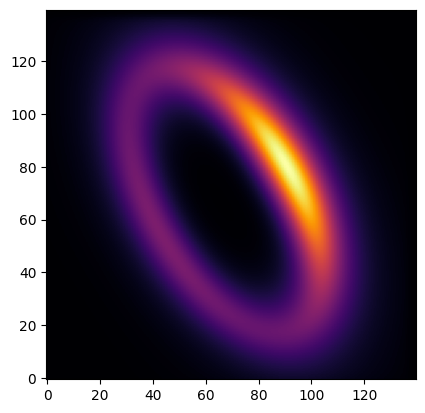

In [4]:
plt.imshow(simple_disk_img, origin='lower', cmap='inferno')

In [6]:
spfs = [[4.0,2.0,1.0,0.5,0.1],[8.0,4.0,1.0,0.2,0.4],[2.0,3.0,2.0,1.0,0.5]]
spfname = []

j = 0
for spf in spfs:
    spf_params = InterpolatedUnivariateSpline_SPF.params
    spf_params['knot_values'] = spf
    spf_params['num_knots'] = len(spf)
    for beta in [-1.0,1.0]:
        for i in [0,15,30,45,60,75,90]:
            disk_params = Parameter_Index.disk_params
            # Setting certain parameters to custom values
            disk_params['sma'] = 25
            disk_params['inclination'] = i
            disk_params['position_angle'] = 45
            disk_params['beta'] = beta
            simple_disk_img = objective_model(disk_params, spf_params, psf_params, misc_params,
                                    ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF)
            if beta>0.5:
                bname = "pos"
                print(bname)
            if beta<-0.5:
                bname = "neg"
            noise_level = 10
            noise = np.random.normal(0, noise_level, simple_disk_img.shape)
            simple_disk_img = simple_disk_img + noise
            fits.writeto("inject_disk_inc{}_spf{}_beta{}.fits".format(i,j,bname), np.asarray(simple_disk_img), overwrite=True)
            plt.imshow(simple_disk_img, origin='lower', cmap='inferno')
            plt.savefig("inject_disk_inc{}_spf{}_beta{}.png".format(i,j,bname),dpi=300)
            plt.show()
    j=j+1
        

KeyboardInterrupt: 

In [ ]:
disk_params

{'accuracy': 0.005,
 'alpha_in': 5,
 'alpha_out': -5,
 'sma': 25,
 'e': 0.0,
 'ksi0': 3.0,
 'gamma': 2.0,
 'beta': 1.0,
 'rmin': 0.0,
 'dens_at_r0': 1.0,
 'inclination': 90,
 'position_angle': 45,
 'x_center': 70.0,
 'y_center': 70.0,
 'halfNbSlices': 25,
 'omega': 0.0}